# Module 4 — Linear Regression

Linear Regression is a fundamental supervised learning algorithm used to model the relationship between a dependent variable and one or more independent variables. It predicts continuous values by fitting a straight line that best represents the data.

- It assumes that there is a linear relationship between the input and output
- Uses a best-fit line to make predictions
- Commonly used in forecasting, trend analysis, and predictive modelling

### Load the Data

We'll use the Hotel Bookings dataset for the examples below.

Here, we will use `lead_time` as an input feature and `adr` (Average Daily Rate) as the continuous value we want to predict.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.read_csv("data/hotel_bookings.csv")

# Handle missing values required for our examples
data["children"] = data["children"].fillna(0)

# Keep valid ADR values
data = data[data["adr"] >= 0]

# Take a smaller sample for easier visualization
data = data.sample(200, random_state=1).reset_index(drop=True)

data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,1,238,2016,September,37,7,0,3,1,...,Non Refund,1.0,NaN,0,Transient,89.0,0,0,Canceled,2016-02-09
1,Resort Hotel,0,19,2017,June,24,17,2,2,2,...,No Deposit,250.0,NaN,0,Transient,167.5,0,0,Check-Out,2017-06-21
2,City Hotel,1,239,2015,October,42,17,0,1,2,...,Non Refund,1.0,NaN,0,Transient,60.0,0,0,Canceled,2015-08-17
3,Resort Hotel,0,64,2015,September,39,24,0,3,2,...,No Deposit,240.0,NaN,0,Transient,80.1,0,2,Check-Out,2015-09-27
4,City Hotel,0,21,2016,October,41,3,1,3,2,...,No Deposit,9.0,NaN,0,Transient,129.0,0,1,Check-Out,2016-10-07


## 1. What is Regression?

**Regression** is a family of machine learning techniques used to predict a **continuous number** — something that can take on a wide range of values, such as a price, temperature, or distance.

Example here: predict **ADR** from **Lead Time**.

Regression tries to learn the mathematical relationship between the input and the continuous output.

In [3]:
print(data[["lead_time", "adr"]].head())

   lead_time    adr
0        238   89.0
1         19  167.5
2        239   60.0
3         64   80.1
4         21  129.0


## 2. Linear Regression

**Linear Regression** is one of the simplest forms of regression. It assumes that the relationship between the input and output can be approximated by fitting a **straight line** through the data.

The basic equation is:

`y = b1*x + b0`

It is fast to train, easy to interpret, and useful as a baseline model before trying more complex algorithms.

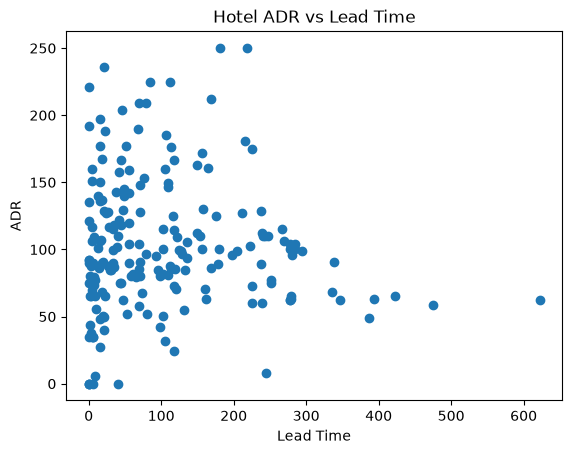

In [4]:
plt.scatter(data["lead_time"], data["adr"])
plt.xlabel("Lead Time")
plt.ylabel("ADR")
plt.title("Hotel ADR vs Lead Time")
plt.show()

## 3. Independent Variable (x)

The **independent variable** is the input feature that we use to make predictions.

Here, `lead_time` is our independent variable because it represents the number of days between the booking date and the arrival date.

In [5]:
x = data[["lead_time"]]
x.head()

,lead_time
0,238
1,19
2,239
3,64
4,21


## 4. Dependent Variable (y)

The **dependent variable** is the output we want to predict.

Here, `adr` (Average Daily Rate) is our dependent variable.

The value of ADR is what our Linear Regression model will try to predict.

In [6]:
y = data["adr"]
y.head()

0     89.0
1    167.5
2     60.0
3     80.1
4    129.0
Name: adr, dtype: float64

## 5. Simple Linear Regression

**Simple Linear Regression** uses exactly **one input variable** to predict one output variable.

Here:

- Input (`x`) → `lead_time`
- Output (`y`) → `adr`

The model will learn the relationship between lead time and the Average Daily Rate.

In [7]:
model = LinearRegression()

model.fit(x, y)

print("Model trained!")
print(data[["lead_time", "adr"]].head())

Model trained!
   lead_time    adr
0        238   89.0
1         19  167.5
2        239   60.0
3         64   80.1
4         21  129.0


## 6. Multiple Linear Regression

**Multiple Linear Regression** uses **two or more inputs** to predict one output.

Here we use:

- `lead_time`
- `adults`
- `children`
- `babies`
- `total_of_special_requests`

to predict `adr`.

Instead of fitting a single line, the model learns the relationship using multiple input features.

In [8]:
x_multi = data[
    [
        "lead_time",
        "adults",
        "children",
        "babies",
        "total_of_special_requests"
    ]
]

y_multi = data["adr"]

model2 = LinearRegression()

model2.fit(x_multi, y_multi)

print("Coefficients:", model2.coef_)
print("Intercept:", model2.intercept_)

Coefficients: [-1.97911260e-02  3.87221664e+01  3.30862593e+01  3.86394214e+01
  9.40047131e+00]
Intercept: 24.812641376266868


In [9]:
b1 = model.coef_[0]
b0 = model.intercept_

x_value = 10

y_value = b1 * x_value + b0

print("y =", y_value)

y = 104.03747126183967


## 8. Coefficient

The **coefficient** tells us how much the predicted `y` changes when `x` increases by one unit.

- A positive coefficient → as x increases, y tends to increase
- A negative coefficient → as x increases, y tends to decrease
- A larger absolute value → a larger change in the prediction per unit of x

The coefficient describes an association in the fitted model; it does not by itself establish causation.

In [10]:
print("Coefficient:", model.coef_[0])

Coefficient: -0.019082466715236772


## 9. Intercept

The **intercept** is the predicted value of `y` when `x = 0`.

It is where the fitted line crosses the y-axis.

In our example, it represents the model's predicted ADR when `lead_time` is zero.

In [11]:
print("Intercept:", model.intercept_)

Intercept: 104.22829592899204


## 10. Prediction

**Prediction** is the main purpose of training a machine learning model.

Once the model has learned the coefficient and intercept, we can provide new `lead_time` values and predict the corresponding ADR.

In [12]:
new_data = pd.DataFrame({
    "lead_time": [10, 50, 100]
})

y_pred = model.predict(new_data)

print("Predicted ADR:")
print(y_pred)

Predicted ADR:
[104.03747126 103.27417259 102.32004926]


## 11. Residuals

A **residual** is the difference between the actual value and the predicted value.

`Residual = Actual - Predicted`

Residuals tell us how far each prediction is from the actual value.

A good regression model generally has residuals that are small and do not show an obvious pattern.

In [13]:
y_pred = model.predict(x)

residual = y - y_pred

residual.head()

0   -10.686669
1    63.634271
2   -39.667586
3   -22.907018
4    25.172436
Name: adr, dtype: float64

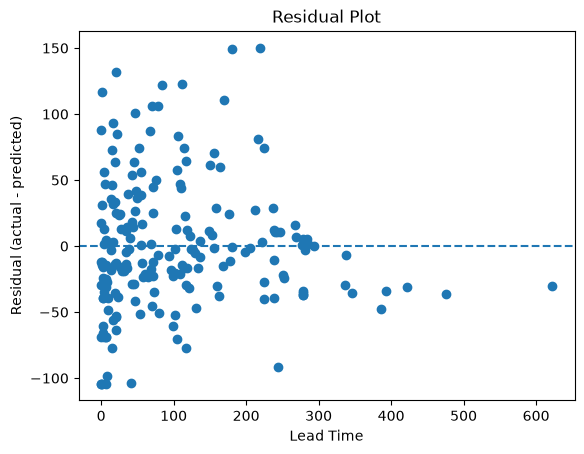

In [14]:
plt.scatter(x["lead_time"], residual)
plt.axhline(0, linestyle="--")
plt.xlabel("Lead Time")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot")
plt.show()

## 12. Least Squares

**Least Squares** (specifically, Ordinary Least Squares) is the mathematical method used by `LinearRegression()` to find the best-fitting coefficient and intercept.

The best-fitting line is the line that minimizes the **sum of squared residuals**.

Squaring the errors prevents positive and negative errors from cancelling each other out and gives more importance to larger errors.

In [15]:
x_arr = data["lead_time"].values
y_arr = data["adr"].values

b1_manual = np.sum(
    (x_arr - x_arr.mean()) * (y_arr - y_arr.mean())
) / np.sum(
    (x_arr - x_arr.mean()) ** 2
)

b0_manual = y_arr.mean() - b1_manual * x_arr.mean()

print("Coefficient (manual):", b1_manual)
print("Intercept (manual):  ", b0_manual)

print("Coefficient (sklearn):", model.coef_[0])
print("Intercept (sklearn):  ", model.intercept_)

Coefficient (manual): -0.01908246671523679
Intercept (manual):   104.22829592899205
Coefficient (sklearn): -0.019082466715236772
Intercept (sklearn):   104.22829592899204


## 13. Cost Function

A **cost function** measures how wrong the model's predictions are overall.

For Linear Regression, **Mean Squared Error (MSE)** is commonly used.

MSE is the average of the squared residuals.

A smaller MSE means the predictions are closer to the actual values.

In [16]:
cost = np.mean((y - y_pred) ** 2)

print("Cost (MSE):", cost)

Cost (MSE): 2429.450522372732


## 14. Gradient Descent — Introduction

**Gradient Descent** is an optimization technique used to minimize a cost function.

Instead of calculating the best parameters directly, it starts with initial values and repeatedly updates the parameters in the direction that reduces the cost.

The basic process is:

1. Start with initial values for the parameters.
2. Calculate the cost.
3. Find the direction that reduces the cost.
4. Update the parameters.
5. Repeat until the cost becomes smaller.

The **learning rate** controls the size of each update.

- A learning rate that is too large can cause the model to overshoot.
- A learning rate that is too small can make learning very slow.

In this notebook, Gradient Descent is introduced conceptually rather than implemented from scratch.

## Conclusion

In this notebook, we learned:

- What Regression is
- Linear Regression
- Simple Linear Regression
- Multiple Linear Regression
- Independent Variables
- Dependent Variables
- Equation of a Line
- Coefficients
- Intercept
- Prediction
- Residuals
- Least Squares
- Cost Function
- Gradient Descent

We implemented Linear Regression using Scikit-learn and calculated the coefficient and intercept manually using NumPy to understand the underlying mathematics.